In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random

np.random.seed(0)
random.seed(0)

## Task 1

In [2]:
# SIS model on ER graph

In [4]:
# assigning infected nodes

def initialize_graph(G, infected_prob):
    for node in G.nodes:
        G.nodes[node]["infected"] = random.random() < infected_prob

def split_nodes(G):
    infected_nodes = []
    susceptible_nodes = []
    for node in G.nodes:
        if G.nodes[node]["infected"]:
            infected_nodes.append(node)
        else:
            susceptible_nodes.append(node)
    return infected_nodes, susceptible_nodes

def get_proportions(G):
    n = len(G.nodes)
    infected_nodes, susceptible_nodes = split_nodes(G)
    i = len(infected_nodes) / n
    s = 1 - i
    return i, s

def step(G, beta, gamma):
    infected_nodes, susceptible_nodes = split_nodes(G)
    
    # S -> I
    for node in susceptible_nodes:
        # there is at least one infected neighbor
        n_infected_neighbors = len([neighbor for neighbor in nx.neighbors(G, node) if G.nodes[neighbor]["infected"]])
        if n_infected_neighbors > 0:
            if random.random() < 1 - (1 - beta) ** n_infected_neighbors:
                G.nodes[node]["infected"] = True
    
    # I -> S
    for node in infected_nodes:
        if random.random() < gamma:
            G.nodes[node]["infected"] = False
            
def make_simulation(G, beta, gamma, time_steps):
    i_list = []
    s_list = []
    
    # initial fractions
    i0, s0 = get_proportions(G)
    i_list.append(i0)
    s_list.append(s0)
     
    for time in range(time_steps):
        step(G, beta, gamma)
        i, s = get_proportions(G)
        i_list.append(i)
        s_list.append(s)
    
    return i_list, s_list

def repeat_simulations(n_simulations, beta, gamma, time_steps, n, p, infected_prob):
    avg_i_list = np.zeros(time_steps + 1)
    avg_s_list = np.zeros(time_steps + 1)
    
    for i in range(n_simulations):
        G = nx.erdos_renyi_graph(n=n, p=p)
        initialize_graph(G, infected_prob)
        i_list, s_list = make_simulation(G, beta, gamma, time_steps)
        
        avg_i_list = avg_i_list + np.array(i_list)
        avg_s_list = avg_s_list + np.array(s_list)
        
    avg_i_list /= n_simulations
    avg_s_list /= n_simulations
    
    return avg_i_list, avg_s_list

In [5]:
n = 100
p = 0.2
infected_prob = 0.5
beta = 0.2 # prob S -> I
gamma = 0.3 # prob I -> S
lmbda = beta / gamma


G = nx.erdos_renyi_graph(n=n, p=p)
initialize_graph(G, infected_prob)

n_simulations = 10
time_steps = 100

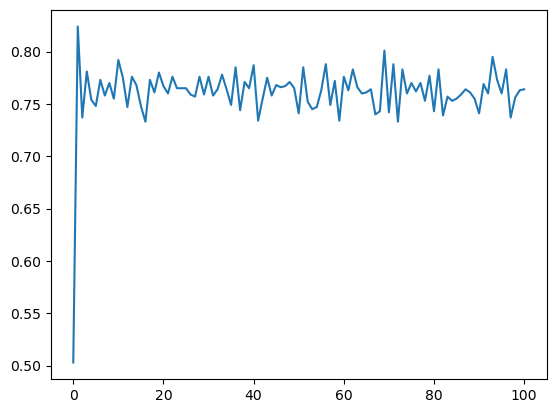

In [6]:
avg_i_list, avg_s_list = repeat_simulations(n_simulations, beta, gamma, time_steps, n, p, infected_prob)
plt.plot(np.arange(time_steps+1), avg_i_list)
plt.show()

In [7]:
# epidemic threshold
# lmbda_c = 1 / (<k> * s0)

# infected proportion in time limit
# i = 0 or 1 - gamma / (<k> * beta)

# scale-free networks (ER): QI(t) = I(t) / N
# i_k = lmbda * k * QI / (1 - lmbda * k * QI)
# and lmbda_c = <k> / <k^2>

In [8]:
n = 100
p = 0.2
infected_prob = 0.5
n_simulations = 10
time_steps = 1000

In [9]:
# epidemic threshold
k_avg = p * (n - 1)
lmbda_c = 1 / k_avg
# lmbda_c = 1 / (n * p * (1 - infected_prob) * n)
lmbda_c

0.050505050505050504

In [10]:
beta_list = np.linspace(0.001, 0.03, 30)
gamma = 0.5
lmbda_list = beta_list / gamma
print(lmbda_list)

[0.002 0.004 0.006 0.008 0.01  0.012 0.014 0.016 0.018 0.02  0.022 0.024
 0.026 0.028 0.03  0.032 0.034 0.036 0.038 0.04  0.042 0.044 0.046 0.048
 0.05  0.052 0.054 0.056 0.058 0.06 ]


In [11]:
infected_list = []

for beta in beta_list:
    avg_i_list, avg_s_list = repeat_simulations(n_simulations, beta, gamma, time_steps, n, p, infected_prob)
    infected_list.append(avg_i_list[-1])

In [12]:
expected_i = np.clip(1 - gamma / (k_avg * beta_list), 0, 1)

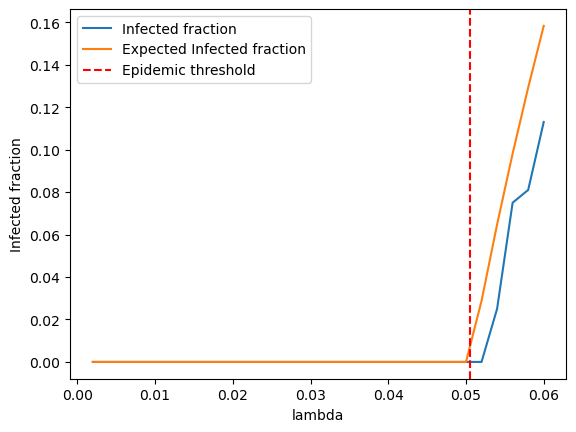

In [13]:
plt.plot(lmbda_list, infected_list)
plt.plot(lmbda_list, expected_i)
plt.xlabel('lambda')
plt.ylabel('Infected fraction')
plt.axvline(lmbda_c, linestyle='--', color='r')
plt.legend(['Infected fraction', 'Expected Infected fraction', 'Epidemic threshold'])
plt.show()